# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler





# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [5]:
!unzip -o "archive (16).zip"

Archive:  archive (16).zip
  inflating: Churn_Modelling.csv     


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

=== 5 Baris Pertama Data Nasabah ===
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3    

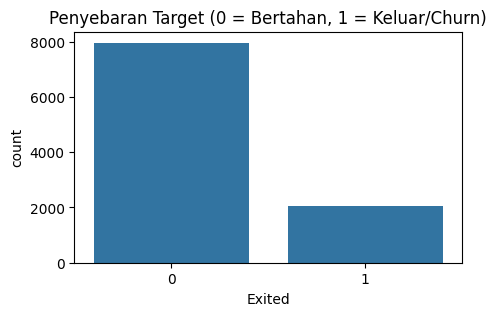

In [6]:

df_churn = pd.read_csv('Churn_Modelling.csv')

print("=== 5 Baris Pertama Data Nasabah ===")
print(df_churn.head())

print("\n=== Cek Data Kosong ===")
print(df_churn.isnull().sum())

print("\n=== Cek Data Duplikat ===")
print(f"Total data duplikat: {df_churn.duplicated().sum()}")

# Menggambar grafik penyebaran target nasabah
plt.figure(figsize=(5, 3))
sns.countplot(x='Exited', data=df_churn)
plt.title('Penyebaran Target (0 = Bertahan, 1 = Keluar/Churn)')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
from sklearn.preprocessing import OneHotEncoder

# 1. Membuang kolom identitas acak yang tidak penting untuk prediksi keuangan
X = df_churn.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Exited'])
y = df_churn['Exited']

# 2. Membagi data menjadi 80% Latihan (Train) dan 20% Ujian (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scaling: Menyamakan rentang angka kontinu yang nilainya besar-besar (Gaji, Saldo, dll)
num_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
scaler = StandardScaler()
X_train_num = pd.DataFrame(scaler.fit_transform(X_train[num_cols]), columns=num_cols, index=X_train.index)
X_test_num = pd.DataFrame(scaler.transform(X_test[num_cols]), columns=num_cols, index=X_test.index)

# 4. Encoding: Mengubah kolom Teks (Negara & Gender) menjadi angka biner 0 dan 1
cat_cols = ['Geography', 'Gender']
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
X_train_cat = pd.DataFrame(encoder.fit_transform(X_train[cat_cols]), columns=encoder.get_feature_names_out(cat_cols), index=X_train.index)
X_test_cat = pd.DataFrame(encoder.transform(X_test[cat_cols]), columns=encoder.get_feature_names_out(cat_cols), index=X_test.index)

# Kolom yang dari awal sudah berwujud angka biner aman
passthrough_cols = ['HasCrCard', 'IsActiveMember']

# 5. Menggabungkan kembali semua bagian yang sudah bersih
train_clean = pd.concat([X_train_num, X_train[passthrough_cols], X_train_cat, y_train], axis=1)
test_clean = pd.concat([X_test_num, X_test[passthrough_cols], X_test_cat, y_test], axis=1)

# 6. Menyimpan ke folder 'namadataset_preprocessing' sesuai instruksi Dicoding
import os
os.makedirs('namadataset_preprocessing', exist_ok=True)
train_clean.to_csv('namadataset_preprocessing/train_clean.csv', index=False)
test_clean.to_csv('namadataset_preprocessing/test_clean.csv', index=False)

print("=== Preprocessing Eksperimen Sukses! ===")
print(f"Data latihan siap pakai disimpan dengan ukuran tabel: {train_clean.shape}")

=== Preprocessing Eksperimen Sukses! ===
Data latihan siap pakai disimpan dengan ukuran tabel: (8000, 14)
